In [170]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [171]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q torchmetrics
!pip install -q opencv-python
!pip install -q tqdm

In [172]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import segmentation_models_pytorch as smp

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

In [173]:
!git clone https://github.com/alexgkendall/SegNet-Tutorial.git

fatal: destination path 'SegNet-Tutorial' already exists and is not an empty directory.


In [174]:
import os

base = "/kaggle/working/SegNet-Tutorial/CamVid"

print("Train Images :", len(os.listdir(base + "/train")))
print("Train Masks  :", len(os.listdir(base + "/trainannot")))

print("Validation Images :", len(os.listdir(base + "/val")))
print("Validation Masks  :", len(os.listdir(base + "/valannot")))

print("Test Images :", len(os.listdir(base + "/test")))
print("Test Masks  :", len(os.listdir(base + "/testannot")))

Train Images : 367
Train Masks  : 367
Validation Images : 101
Validation Masks  : 101
Test Images : 233
Test Masks  : 233


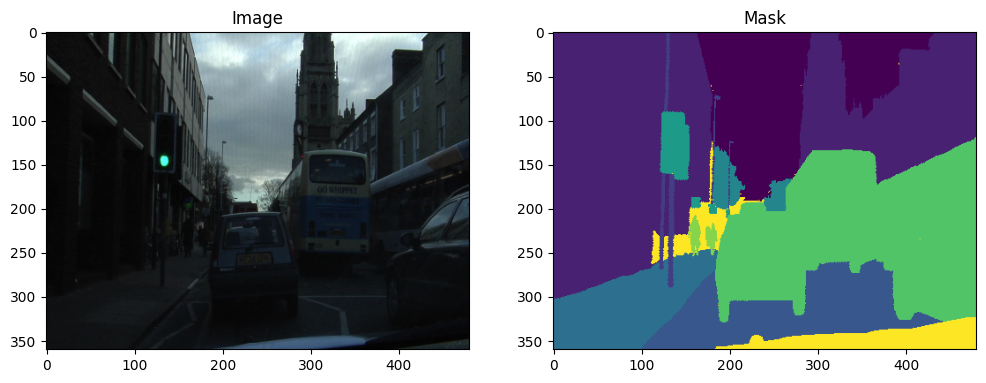

In [175]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base = "SegNet-Tutorial/CamVid"

img_name = sorted(os.listdir(base + "/train"))[0]

image = Image.open(os.path.join(base, "train", img_name))
mask = Image.open(os.path.join(base, "trainannot", img_name))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

In [176]:
print(image.size)
print(mask.size)

(480, 360)
(480, 360)


In [177]:
import numpy as np

mask_np = np.array(mask)

print(mask_np.shape)
print(np.unique(mask_np)[:20])

(360, 480)
[ 0  1  2  3  4  5  6  8  9 11]


In [178]:
class CamVidDataset(Dataset):
    def __init__(self, root, split="train", transforms=None):
        self.root = root
        self.split = split
        self.transforms = transforms

        self.images_dir = os.path.join(root, split)
        self.masks_dir = os.path.join(root, split + "annot")

        self.images = sorted(os.listdir(self.images_dir))
        self.masks = sorted(os.listdir(self.masks_dir))

        # Safety check
        assert len(self.images) == len(self.masks), "Images and masks count mismatch"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))

        if self.transforms:
            augmented = self.transforms(
                image=np.array(image),
                mask=mask
            )
            image = augmented["image"]
            mask = augmented["mask"]

        # CrossEntropyLoss expects LongTensor targets
        mask = torch.as_tensor(mask, dtype=torch.long)

        return image, mask

In [179]:
train_transform = A.Compose([

    A.RandomResizedCrop(
    size=(368,480),
    scale=(0.7,1.0),
    ratio=(0.9,1.1),
    p=1.0
    ),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(

        shift_limit=0.05,

        scale_limit=0.10,

        rotate_limit=5,

        border_mode=0,

        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.5),

    A.HueSaturationValue(p=0.3),

    A.GaussNoise(p=0.2),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(368, 480),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [180]:
NUM_CLASSES = 12
ROOT = "SegNet-Tutorial/CamVid"
train_dataset = CamVidDataset(
    root=ROOT,
    split="train",
    transforms=train_transform
)

val_dataset = CamVidDataset(
    root=ROOT,
    split="val",
    transforms=val_test_transform
)

test_dataset = CamVidDataset(
    root=ROOT,
    split="test",
    transforms=val_test_transform
)
print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))
print("test Dataset :", len(test_dataset))

Train Dataset : 367
Validation Dataset : 101
test Dataset : 233


In [181]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [182]:
images, masks = next(iter(train_loader))

print(images.shape)
print(images.dtype)

print(masks.shape)
print(masks.dtype)

print(torch.unique(masks))

torch.Size([8, 3, 368, 480])
torch.float32
torch.Size([8, 368, 480])
torch.int64
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [183]:
model = smp.DeepLabV3Plus(
    encoder_name="resnet101",
    encoder_weights="imagenet",
    classes=NUM_CLASSES,
)
images, masks = next(iter(train_loader))

outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

Input : torch.Size([8, 3, 368, 480])
Output: torch.Size([8, 12, 368, 480])


In [184]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model = model.to(device)

cuda


In [185]:
class_counts = torch.tensor([
    10682767,
    14750079,
    623349,
    20076880,
    2845085,
    6166762,
    743859,
    714595,
    3719877,
    405385,
    184967,
    2503995
], dtype=torch.float)

weights = class_counts.sum() / (len(class_counts) * class_counts)
weights = weights / weights.mean()

# criterion = nn.CrossEntropyLoss(
#     weight=weights.to(device)
# )

In [186]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, outputs, targets):

        probs = torch.softmax(outputs, dim=1)

        targets = F.one_hot(
            targets,
            num_classes=outputs.shape[1]
        ).permute(0,3,1,2).float()

        intersection = (probs * targets).sum((2,3))

        union = probs.sum((2,3)) + targets.sum((2,3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        return 1 - dice.mean()

In [187]:
dice_loss = DiceLoss()

ce_loss = nn.CrossEntropyLoss(
    weight=weights.to(device)
)

In [188]:
optimizer = torch.optim.AdamW(
    [
        {"params": model.encoder.parameters(), "lr": 1e-4},
        {"params": model.decoder.parameters(), "lr": 1e-3},
        {"params": model.segmentation_head.parameters(), "lr": 1e-3},
    ],
    weight_decay=1e-4,
)

In [189]:

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[1e-4, 1e-3, 1e-3],
    epochs=70,
    steps_per_epoch=len(train_loader),
    pct_start=0.3,
    anneal_strategy="cos"
)

In [190]:
def pixel_accuracy(outputs, masks):

    preds = outputs.argmax(dim=1)

    correct = (preds == masks).float()

    acc = correct.sum() / correct.numel()

    return acc.item()

In [191]:
# def mean_iou(outputs, masks, num_classes=12):

#     preds = outputs.argmax(dim=1)

#     ious = []

#     for cls in range(num_classes):

#         pred_inds = (preds == cls)
#         target_inds = (masks == cls)

#         intersection = (pred_inds & target_inds).sum().item()

#         union = (pred_inds | target_inds).sum().item()

#         if union == 0:
#             continue

#         ious.append(intersection / union)

#     if len(ious) == 0:
#         return 0

#     return sum(ious) / len(ious)

In [192]:
class IoUMetric:

    def __init__(self, num_classes):

        self.num_classes = num_classes
        self.reset()

    def reset(self):

        self.intersection = torch.zeros(self.num_classes)
        self.union = torch.zeros(self.num_classes)

    @torch.no_grad()
    def update(self, outputs, targets):

        preds = outputs.argmax(1)

        for c in range(self.num_classes):

            pred = preds == c
            target = targets == c

            inter = (pred & target).sum().cpu()
            union = (pred | target).sum().cpu()

            self.intersection[c] += inter
            self.union[c] += union

    def compute(self):

        iou = self.intersection / (self.union + 1e-6)

        valid = self.union > 0

        return iou[valid].mean().item(), iou

In [193]:
from tqdm import tqdm
from torch.amp import autocast
from torch.amp import GradScaler

scaler = GradScaler("cuda")

def train_one_epoch(model,
                    loader,
                    optimizer,
                    device):

    model.train()

    running_loss = 0
    running_acc = 0
    running_iou = 0

    iou_metric = IoUMetric(NUM_CLASSES)

    progress = tqdm(loader)

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
             outputs = model(images)
             loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )
        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        acc = pixel_accuracy(outputs, masks)

        # iou = mean_iou(outputs, masks)
        iou_metric.update(outputs, masks)

        running_loss += loss.item()
        running_acc += acc
        # running_iou += iou

        progress.set_postfix(
            loss=loss.item(),
            acc=acc
        )

    epoch_iou, per_class_iou = iou_metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        epoch_iou,
        per_class_iou
    )

In [194]:
@torch.no_grad()
def validate(model,
             loader,
             device):

    model.eval()

    iou_metric = IoUMetric(NUM_CLASSES)

    running_loss = 0
    running_acc = 0
    running_iou = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        with autocast(device_type="cuda"):
             outputs = model(images)
             loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

        acc = pixel_accuracy(outputs, masks)
        iou_metric.update(outputs, masks)

        # iou = mean_iou(outputs, masks)

        running_loss += loss.item()
        running_acc += acc
        # running_iou += iou
    epoch_iou, per_class_iou = iou_metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        epoch_iou,
        per_class_iou
    )

In [195]:
epochs = 70
NUM_CLASSES = 12
best_iou = 0

patience = 12          # stop after 12 epochs without improvement
epochs_no_improve = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(epochs):

    train_loss, train_acc, train_iou, train_per_class_iou = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss, val_acc, val_iou, val_per_class_iou = validate(
        model,
        val_loader,
        device
    )

    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print("Train per-class IoU:", train_per_class_iou)
    print("Val per-class IoU:", val_per_class_iou)

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")

    print(f"Val IoU    : {val_iou:.4f}")

    if val_iou > best_iou:

        best_iou = val_iou
        epochs_no_improve = 0

        checkpoint = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "best_iou": best_iou,
            "architecture": "DeepLabV3+",
            "encoder": "resnet101"
        }

        torch.save(checkpoint, "best_deeplabv3plus_checkpoint.pth")

        print(" Model Saved")

    else:

        epochs_no_improve += 1

        print(f"No improvement for {epochs_no_improve}/{patience} epochs.")

        if epochs_no_improve >= patience:

            print("\nEarly stopping triggered!")
            break

print(f"\nBest Validation IoU: {best_iou:.4f}")

100%|██████████| 46/46 [00:15<00:00,  3.03it/s, acc=0.438, loss=2.96] 


Train per-class IoU: tensor([0.2470, 0.0933, 0.0152, 0.3594, 0.0348, 0.1455, 0.0326, 0.0284, 0.2150,
        0.0154, 0.0141, 0.0353])
Val per-class IoU: tensor([0.6667, 0.0287, 0.0050, 0.6040, 0.1935, 0.5210, 0.0937, 0.1650, 0.3434,
        0.0998, 0.1716, 0.0318])

Epoch 1/70
Train Loss : 3.2066
Val Loss   : 2.6020
Train IoU  : 0.1030
Val IoU    : 0.2437
 Model Saved


100%|██████████| 46/46 [00:14<00:00,  3.08it/s, acc=0.656, loss=2.5] 


Train per-class IoU: tensor([0.6361, 0.2778, 0.0299, 0.7116, 0.1682, 0.3627, 0.0788, 0.1071, 0.3616,
        0.0913, 0.0426, 0.0590])
Val per-class IoU: tensor([0.7969, 0.3765, 0.0161, 0.6645, 0.3527, 0.8007, 0.1106, 0.2736, 0.4965,
        0.0859, 0.1824, 0.0260])

Epoch 2/70
Train Loss : 2.6670
Val Loss   : 1.8168
Train IoU  : 0.2439
Val IoU    : 0.3485
 Model Saved


100%|██████████| 46/46 [00:14<00:00,  3.16it/s, acc=0.704, loss=2.11]


...

Train per-class IoU: tensor([0.9276, 0.8715, 0.3308, 0.9671, 0.7771, 0.8067, 0.6218, 0.7569, 0.8732,
        0.4866, 0.6128, 0.5786])
Val per-class IoU: tensor([0.9365, 0.8390, 0.1827, 0.9621, 0.8722, 0.9089, 0.5674, 0.6255, 0.8464,
        0.4749, 0.7598, 0.2394])

Epoch 68/70
Train Loss : 0.6091
Val Loss   : 0.6717
Train IoU  : 0.7176
Val IoU    : 0.6846
 Model Saved


100%|██████████| 46/46 [00:14<00:00,  3.13it/s, acc=0.936, loss=0.57] 


Train per-class IoU: tensor([0.9273, 0.8708, 0.3406, 0.9660, 0.7800, 0.8104, 0.6176, 0.7706, 0.8760,
        0.4952, 0.5730, 0.5809])
Val per-class IoU: tensor([0.9361, 0.8393, 0.1824, 0.9618, 0.8718, 0.9086, 0.5648, 0.6302, 0.8467,
        0.4678, 0.7567, 0.2393])

Epoch 69/70
Train Loss : 0.6065
Val Loss   : 0.6649
Train IoU  : 0.7174
Val IoU    : 0.6838
No improvement for 1/12 epochs.


100%|██████████| 46/46 [00:14<00:00,  3.14it/s, acc=0.933, loss=0.62] 


Train per-class IoU: tensor([0.9286, 0.8688, 0.3351, 0.9666, 0.7765, 0.8007, 0.6142, 0.7431, 0.8756,
        0.4998, 0.6267, 0.5822])
Val per-class IoU: tensor([0.9359, 0.8359, 0.1825, 0.9614, 0.8697, 0.9087, 0.5676, 0.6220, 0.8463,
        0.4709, 0.7552, 0.2387])

Epoch 70/70
Train Loss : 0.6074
Val Loss   : 0.6661
Train IoU  : 0.7182
Val IoU    : 0.6829
No improvement for 2/12 epochs.

Best Validation IoU: 0.6846


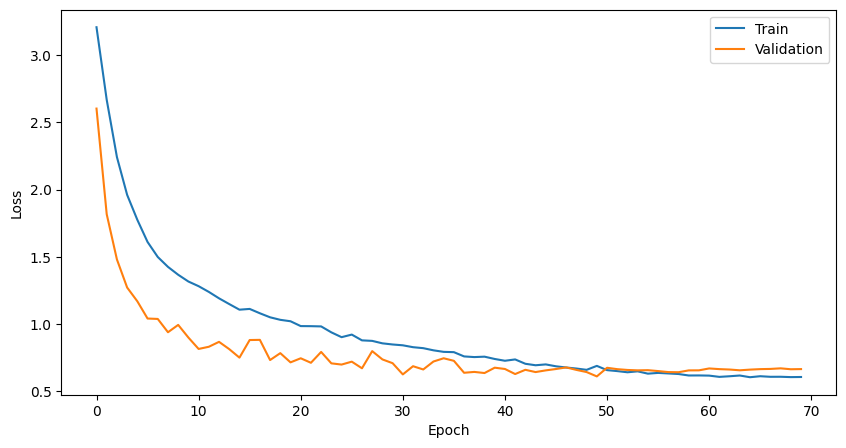

In [196]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train")

plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [197]:
from collections import Counter

counter = Counter()

for _, masks in train_loader:
    counter.update(masks.flatten().tolist())

print(counter)

Counter({3: 20996756, 0: 14254945, 1: 13027986, 5: 5883596, 8: 3561329, 11: 2333063, 4: 2288897, 6: 699199, 2: 633501, 7: 593644, 9: 390753, 10: 163211})


In [198]:
from collections import Counter

pred_counter = Counter()

model.eval()

with torch.no_grad():

    for images, _ in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1).cpu()

        pred_counter.update(preds.flatten().tolist())

print(pred_counter)

Counter({3: 5000779, 1: 4024325, 5: 3030752, 4: 1678253, 0: 1611336, 7: 747162, 10: 490674, 11: 471128, 8: 305121, 9: 209393, 6: 161970, 2: 109747})


In [199]:
@torch.no_grad()
def evaluate_test(model, loader, device, num_classes):

    model.eval()

    metric = IoUMetric(num_classes)

    running_loss = 0
    running_acc = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        with autocast(device_type="cuda"):

            outputs = model(images)
            loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

        running_loss += loss.item()
        running_acc += pixel_accuracy(outputs, masks)

        metric.update(outputs, masks)

    miou, per_class_iou = metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        miou,
        per_class_iou
    )

In [200]:
checkpoint = torch.load(
    "best_deeplabv3plus_checkpoint.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model"])

print("Loaded best model from epoch", checkpoint["epoch"] + 1)
print("Best Validation IoU:", checkpoint["best_iou"])

Loaded best model from epoch 68
Best Validation IoU: 0.6845545768737793


In [201]:
test_loss, test_acc, test_iou, test_per_class_iou = evaluate_test(
    model,
    test_loader,
    device,
    NUM_CLASSES
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Pixel Accuracy : {test_acc:.4f}")
print(f"Test mIoU : {test_iou:.4f}")

Test Loss : 1.6045
Pixel Accuracy : 0.8667
Test mIoU : 0.5870


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


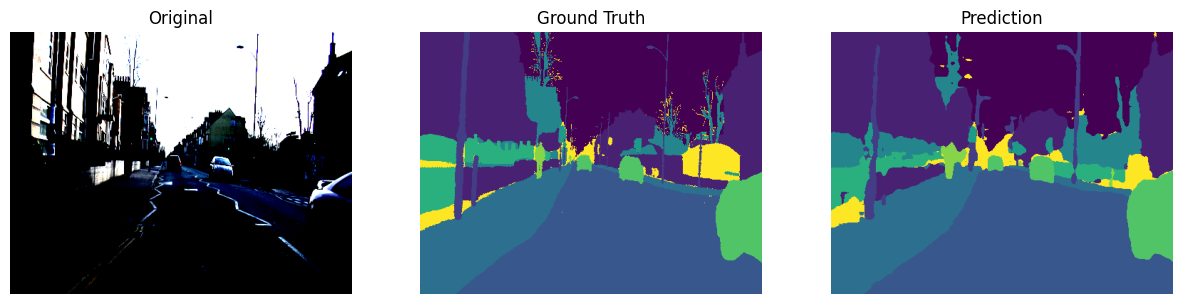

In [207]:
import matplotlib.pyplot as plt
import random

model.eval()

idx = random.randint(0, len(test_dataset)-1)

image, mask = test_dataset[idx]

with torch.no_grad():

    pred = model(image.unsqueeze(0).to(device))
    pred = pred.argmax(1).squeeze().cpu()

image = image.permute(1,2,0)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")
plt.axis("off")

plt.show()

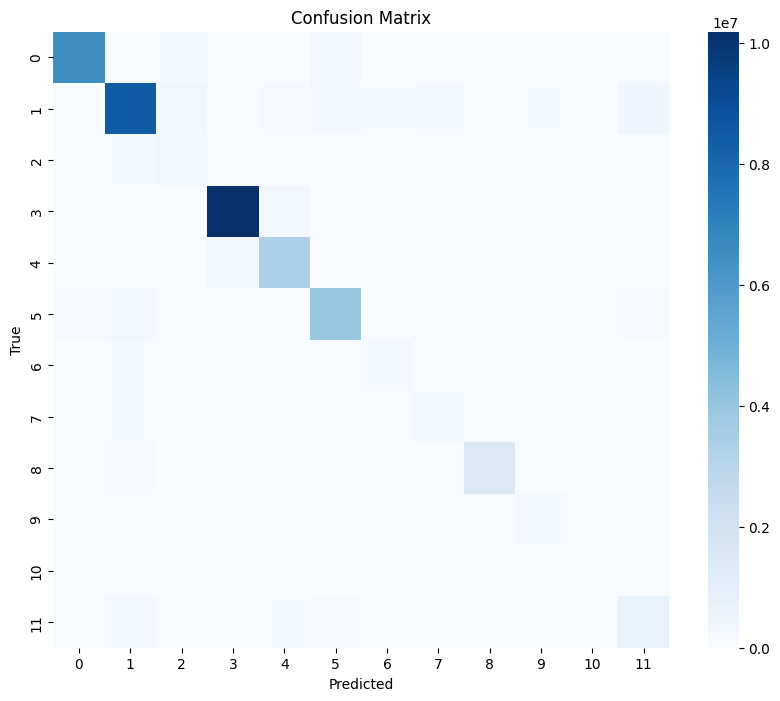

In [203]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1).cpu()

        all_preds.extend(preds.view(-1).numpy())
        all_targets.extend(masks.view(-1).numpy())

cm = confusion_matrix(
    all_targets,
    all_preds,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues",
    square=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [204]:
class_names = [
    "Sky",
    "Building",
    "Pole",
    "Road",
    "Pavement",
    "Tree",
    "Sign",
    "Fence",
    "Car",
    "Pedestrian",
    "Bicyclist",
    "Unlabelled"
]

print("-"*35)

for i in range(NUM_CLASSES):

    print(f"{class_names[i]:12s}: {test_per_class_iou[i]:.4f}")

-----------------------------------
Sky         : 0.8921
Building    : 0.7623
Pole        : 0.2484
Road        : 0.9253
Pavement    : 0.7684
Tree        : 0.7113
Sign        : 0.4126
Fence       : 0.2940
Car         : 0.7914
Pedestrian  : 0.4108
Bicyclist   : 0.5221
Unlabelled  : 0.3054


In [205]:
import pandas as pd

iou_table = pd.DataFrame({

    "Class": class_names,
    "IoU": test_per_class_iou.numpy()

})

display(iou_table)

,Class,IoU
0,Sky,0.892074
1,Building,0.762321
2,Pole,0.248366
3,Road,0.925331
4,Pavement,0.768409
5,Tree,0.711283
6,Sign,0.412645
7,Fence,0.293972
8,Car,0.791438
9,Pedestrian,0.410757
